   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 59.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 12.9 MB/s eta 0:00:00
✅ Arquivos encontrados! Carregando com sktime...
Dataset carregado: 5000 séries, 140 pontos cada.
Rótulos: ['1' '2' '3' '4' '5']

--- Treinando autoencoder com latent_dim = 8 ---
Epoch 0/20, loss: 0.4343
Epoch 5/20, loss: 0.0347
Epoch 10/20, loss: 0.0287
Epoch 15/20, loss: 0.0261
  R_ratio = 0.414 | effrank = 8 | PC1 var = 68.0%

--- Treinando autoencoder com latent_dim = 16 ---
Epoch 0/20, loss: 0.4013
Epoch 5/20, loss: 0.0268
Epoch 10/20, loss: 0.0187
Epoch 15/20, loss: 0.0153
  R_ratio = 0.593 | effrank = 16 | PC1 var = 50.8%

--- Treinando autoencoder com latent_dim = 32 ---
Epoch 0/20, loss: 0.3921
Epoch 5/20, loss: 0.0255
Epoch 10/20, loss: 0.0168
Epoch 15/20, loss: 0.0131
  R_ratio = 0.589 | effrank = 20 | PC1 var = 38.7%

=== Resultados SCD no ECG5000 ===
 latent_dim  R_ratio  effrank  PC1_var(%)  NDC-6 violat

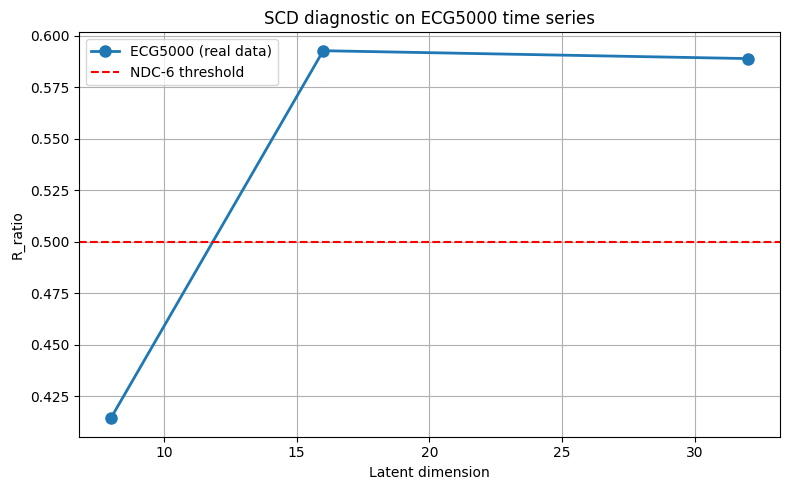


✅ Experimento concluído. Figura salva: ecg5000_sensitivity_Rratio.tiff (1200 dpi)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os
import warnings
warnings.filterwarnings('ignore')

# Instalar sktime (se não estiver disponível)
try:
    from sktime.datasets import load_from_tsfile
except ImportError:
    !pip install sktime -q
    from sktime.datasets import load_from_tsfile

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# =============================================================================
# 1. Caminho do seu dataset
# =============================================================================
BASE_PATH = "/kaggle/input/datasets/leonardocpaesbarreto/scd-on-ecg5000-data"
train_path = os.path.join(BASE_PATH, "ECG5000_TRAIN.ts")
test_path = os.path.join(BASE_PATH, "ECG5000_TEST.ts")

# Verificar se os arquivos existem
if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError("Arquivos .ts não encontrados. Verifique o caminho.")

print("✅ Arquivos encontrados! Carregando com sktime...")

# Carregar usando sktime (lida com cabeçalhos e metadados)
X_train, y_train = load_from_tsfile(train_path, return_data_type='numpy2d')
X_test, y_test = load_from_tsfile(test_path, return_data_type='numpy2d')

# Concatenar
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

print(f"Dataset carregado: {X.shape[0]} séries, {X.shape[1]} pontos cada.")
print(f"Rótulos: {np.unique(y)}")

# =============================================================================
# 2. Normalização (z-score por série)
# =============================================================================
X_norm = np.zeros_like(X)
for i in range(X.shape[0]):
    X_norm[i] = (X[i] - X[i].mean()) / (X[i].std() + 1e-8)

# =============================================================================
# 3. Autoencoder
# =============================================================================
class TimeSeriesAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

def train_ae(X, latent_dim, epochs=20, batch_size=64):
    dataset = TensorDataset(torch.tensor(X.astype(np.float32)))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = TimeSeriesAE(X.shape[1], latent_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for (x,) in loader:
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{epochs}, loss: {total_loss/len(loader):.4f}")
    return model

# =============================================================================
# 4. Executar experimento para diferentes dimensões latentes
# =============================================================================
latent_dims = [8, 16, 32]
results = []

for ld in latent_dims:
    print(f"\n--- Treinando autoencoder com latent_dim = {ld} ---")
    model = train_ae(X_norm, ld, epochs=20, batch_size=64)
    model.eval()
    with torch.no_grad():
        _, Z = model(torch.tensor(X_norm.astype(np.float32)))
    Z = Z.numpy()
    
    kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(Z)
    
    runs = 1 + np.sum(labels[:-1] != labels[1:])
    n_k = np.bincount(labels, minlength=4)
    N = len(labels)
    R_null = 1 + (N*N - np.sum(n_k*n_k)) / N
    R_ratio = runs / R_null
    
    _, S, _ = np.linalg.svd(Z, full_matrices=False)
    eff_rank = np.sum(S > 0.01 * S[0])
    
    pca = PCA(n_components=1)
    pca.fit(Z)
    pc1_var = pca.explained_variance_ratio_[0] * 100
    
    results.append({
        'latent_dim': ld,
        'R_ratio': R_ratio,
        'effrank': eff_rank,
        'PC1_var(%)': pc1_var,
        'NDC-6 violated': R_ratio < 0.5
    })
    print(f"  R_ratio = {R_ratio:.3f} | effrank = {eff_rank} | PC1 var = {pc1_var:.1f}%")

df_results = pd.DataFrame(results)
print("\n=== Resultados SCD no ECG5000 ===")
print(df_results.to_string(index=False))

# =============================================================================
# 5. Figura (TIFF 1200 dpi)
# =============================================================================
plt.figure(figsize=(8,5))
plt.plot(df_results['latent_dim'], df_results['R_ratio'], 'o-', linewidth=2, markersize=8, label='ECG5000 (real data)')
plt.axhline(0.5, color='red', linestyle='--', label='NDC-6 threshold')
plt.xlabel('Latent dimension')
plt.ylabel('R_ratio')
plt.title('SCD diagnostic on ECG5000 time series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ecg5000_sensitivity_Rratio.tiff', dpi=1200, format='tiff', pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig('ecg5000_sensitivity_Rratio.png', dpi=150)
plt.show()

print("\n✅ Experimento concluído. Figura salva: ecg5000_sensitivity_Rratio.tiff (1200 dpi)")